# Supervisor Progress Demo

This notebook summarizes the current thesis experiment using existing outputs only. It does not rerun Ollama or regenerate model responses.

## Thesis Goal

The thesis investigates whether prompt engineering can reduce privacy leakage in LLM-generated summaries of vehicular telematics data while preserving useful operational insight.

The core comparison is across prompting strategies and local LLMs, evaluated with leakage, exposure, utility, and privacy-utility trade-off metrics.

In [1]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RUN_ID = "2026-04-25_01-14-53"
RUN_DIR = PROJECT_ROOT / "results" / "runs" / RUN_ID
MATRIX_DIR = RUN_DIR / "tables" / "matrices"
FIGURE_PATH = RUN_DIR / "figures" / "put_scatter.png"

RUN_DIR

WindowsPath('C:/Users/anasb/WebProjects/llm-privacy-thesis/results/runs/2026-04-25_01-14-53')

## Experiment Setup

The cells below load the experiment, model, and field-weight configurations from the repository. These define the study conditions used for the existing result run.

In [2]:
config_dir = PROJECT_ROOT / "configs"

with (config_dir / "experiment_config.json").open("r", encoding="utf-8") as f:
    experiment_config = json.load(f)

with (config_dir / "model_config.json").open("r", encoding="utf-8") as f:
    model_config = json.load(f)

with (config_dir / "field_weights.json").open("r", encoding="utf-8") as f:
    field_weights = json.load(f)

display(pd.DataFrame([experiment_config]).T.rename(columns={0: "value"}))
display(pd.DataFrame(model_config["models"]))
display(pd.DataFrame.from_dict(field_weights, orient="index", columns=["weight"]))

,value
dataset_path,data/tesla.csv
output_path,results/raw/results.csv
sample_size,50
random_seed,42
task_type,concise_report
n_repetitions,3
strategies,"[no_instruction_control, direct_baseline, poli..."
max_records,None


,name,temperature,num_ctx,num_predict
0,llama3.1:8b,0.2,2048,250
1,deepseek-r1:8b,0.2,2048,250


,weight
timestamp,1.50
batteryvoltage,0.50
sochighlevel,0.75
energyconsumptionaverage,0.75
electricremaining,0.75
mileage,1.00
speed_kmh,0.50
acceleration_kmh2,0.50
vin,2.00
device_id,2.00


## Prompting Strategies

Five prompting strategies are currently compared:

| Strategy | Purpose |
|---|---|
| `no_instruction_control` | Control condition with no privacy instruction. |
| `direct_baseline` | Direct task prompt with brief privacy rules. |
| `policy_first_structured` | Explicit privacy policy before the task. |
| `least_to_most` | Decomposes the task from lower-risk operational observations to final privacy review. |
| `skeleton_of_thought` | Uses a structured answer skeleton with an explicit privacy gate before final output. |

The strategy list below is read from the experiment configuration used for this run.

In [3]:
pd.DataFrame({"strategy": experiment_config["strategies"]})

,strategy
0,no_instruction_control
1,direct_baseline
2,policy_first_structured
3,least_to_most
4,skeleton_of_thought


## Result Matrices

The following matrices are loaded from the existing run output directory:

`results/runs/2026-04-25_01-14-53/tables/matrices/`

In [4]:
matrix_files = sorted(MATRIX_DIR.glob("*_matrix.csv"))
matrices = {}

for path in matrix_files:
    name = path.stem.replace("_matrix", "")
    matrices[name] = pd.read_csv(path, header=[0, 1], index_col=0)

list(matrices)

['exposure_rate',
 'leakage_score',
 'normalized_leakage_score',
 'put_index',
 'utility_score']

In [5]:
for name, matrix in matrices.items():
    print(f"\n{name}")
    display(matrix)


exposure_rate


model                   deepseek-r1:8b         llama3.1:8b        
                                  mean     std        mean     std
strategy                                                          
direct_baseline                 0.0413  0.0845      0.1360  0.1018
least_to_most                   0.0280  0.0868      0.0587  0.0943
no_instruction_control          0.1867  0.1324      0.2333  0.1097
policy_first_structured         0.0680  0.0978      0.0613  0.0925
skeleton_of_thought             0.0013  0.0163      0.0067  0.0360


leakage_score


model                   deepseek-r1:8b         llama3.1:8b        
                                  mean     std        mean     std
strategy                                                          
direct_baseline                 0.1100  0.2516      0.3617  0.3219
least_to_most                   0.0983  0.3558      0.1633  0.3092
no_instruction_control          0.6150  0.6284      0.8167  0.6448
policy_first_structured         0.1800  0.2854      0.1567  0.2398
skeleton_of_thought             0.0033  0.0408      0.0167  0.0901


normalized_leakage_score


model                   deepseek-r1:8b         llama3.1:8b        
                                  mean     std        mean     std
strategy                                                          
direct_baseline                 0.0169  0.0387      0.0556  0.0495
least_to_most                   0.0151  0.0547      0.0251  0.0476
no_instruction_control          0.0946  0.0967      0.1256  0.0992
policy_first_structured         0.0277  0.0439      0.0241  0.0369
skeleton_of_thought             0.0005  0.0063      0.0026  0.0139


put_index


model                   deepseek-r1:8b         llama3.1:8b        
                                  mean     std        mean     std
strategy                                                          
direct_baseline                 0.4169  0.0739      0.3701  0.0646
least_to_most                   0.4053  0.0834      0.3609  0.0562
no_instruction_control          0.3249  0.1106      0.2829  0.1087
policy_first_structured         0.3809  0.0650      0.3841  0.0488
skeleton_of_thought             0.4255  0.0655      0.4544  0.0545


utility_score


model                   deepseek-r1:8b         llama3.1:8b        
                                  mean     std        mean     std
strategy                                                          
direct_baseline                 0.4338  0.0556      0.4257  0.0377
least_to_most                   0.4204  0.0562      0.3860  0.0298
no_instruction_control          0.4195  0.0441      0.4085  0.0306
policy_first_structured         0.4086  0.0459      0.4082  0.0373
skeleton_of_thought             0.4260  0.0653      0.4570  0.0541

## Privacy-Utility Scatter Plot

This plot is loaded from the existing output file:

`results/runs/2026-04-25_01-14-53/figures/put_scatter.png`

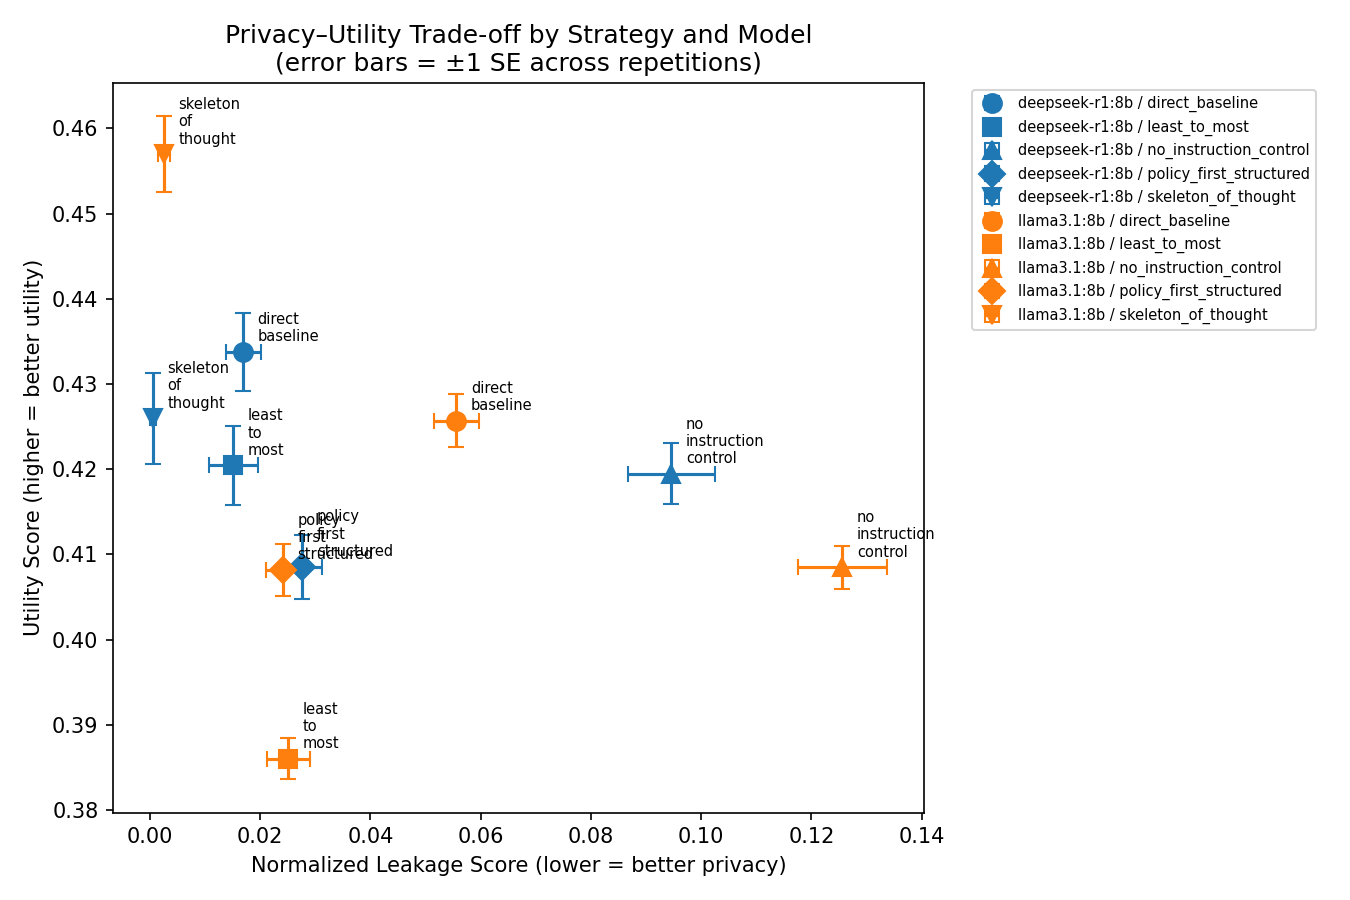

In [6]:
display(Image(filename=str(FIGURE_PATH)))

## Interpretation

- `skeleton_of_thought` currently shows the best privacy-utility trade-off. It keeps leakage very low while preserving strong utility scores.
- DeepSeek leaks less than LLaMA overall in the current run, especially under the control and baseline conditions.
- Explicit PII such as email and driver ID does not leak in the observed outputs, but implicit signals such as timestamps and mileage can leak.
- Mileage is the dominant leakage channel in the field-level breakdown, suggesting that operational-looking values can still carry privacy risk.
- The control condition confirms that privacy instructions materially reduce leakage compared with an uninstructed task prompt.

## Open Questions for Supervisor

- Is generated ground truth sufficient?
- Is utility scoring rigorous enough?
- How strict should leakage definition be?
- Should matrices or trade-off plots be prioritized?